<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/ML_AprendizadoSupervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo

## Aplicar conceitos de Machine Learning (ML) com PyTorch, utilizando:
- Aprendizado Supervisionado: Uso de dados rotulados (Cavalos vs. Outros) extraídos de frames de vídeo.
- Classificação Binária: Modelo treinado para identificar a espécie "Cavalo".
- Engenharia de Features: Extração da altura dos espécimes como variável principal de decisão.
- Análise de Performance: Geração de métricas (Acurácia, Precisão e Recall) e visualização da Fronteira de Decisão e gráfico Loss.



In [1]:
# descompacta pasta
!unzip -q cavalos.zip -d /content/cavalos_data
!unzip -q outros.zip -d /content/outros_data

In [2]:
# coletar dados
# extraindo frames dos videos (videos e apenas uma pilha de imagens)
import cv2
import os

# Configurar onde estão os vídeos e onde salvar as fotos
pasta_videos = '/content/cavalos_data/cavalos'
pasta_destino = '/content/dataset/cavalos'
os.makedirs(pasta_destino, exist_ok=True)

# Lista todos os arquivos da pasta
arquivos = os.listdir(pasta_videos)

for nome_arquivo in arquivos:
    # Caminho completo do vídeo
    caminho_completo = os.path.join(pasta_videos, nome_arquivo)

    # Abre o vídeo
    video = cv2.VideoCapture(caminho_completo)

    # Tira o primeiro frame (sucesso = True/False, imagem = os pixels)
    sucesso, imagem = video.read()

    if sucesso:
        #  Salva a imagem com um nome novo
        nome_foto = nome_arquivo + ".jpg"
        caminho_salvamento = os.path.join(pasta_destino, nome_foto)
        cv2.imwrite(caminho_salvamento, imagem)
        print(f"Sucesso: {nome_foto} extraído!")

    video.release()

Sucesso: 8.mp4.jpg extraído!
Sucesso: 7.mp4.jpg extraído!
Sucesso: 1.mp4.jpg extraído!
Sucesso: 2.mp4.jpg extraído!
Sucesso: 9.mp4.jpg extraído!
Sucesso: 6.mp4.jpg extraído!
Sucesso: 3.mp4.jpg extraído!
Sucesso: 5.mp4.jpg extraído!
Sucesso: 4.mp4.jpg extraído!
Sucesso: 10.mp4.jpg extraído!


In [3]:
# escolha de features - altura_estimada
# Coluna 1: Altura Estimada (em metros)

# matriz de atributos
feacture = [
  # cavalos
  [1.80], [1.80], [1.80], [1.70], [1.80], [1.80], [1.80], [1.80], [1.70], [1.80],
  # outros
  [1.60], [1.60], [1.20], [1.00], [1.60], [1.60], [0.60], [0.50], [0.50], [0.60]
]

# resposta binaria para classificação 1 cavalo / 0 outros
resposta_classificacao = [1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0]


In [15]:
# treinar classificador
# escolher algoritmo
# PyTorch - montando neuronio - perceptron
import torch
import torch.nn as redesNeurais

# PyTorch usa tensores(matrizes para numeros) e não listas
alturasPossiveis = torch.tensor(feacture, dtype=torch.float32)

# O .reshape(-1, 1) transforma a lista [0, 1, 0...] em uma coluna de 20 linhas e 1 coluna
classificacaoPossivel = torch.tensor(resposta_classificacao, dtype=torch.float32).reshape(-1, 1)

# Crio modelo (um neurônio simples) camada linear que aceita 1 entrada e 1 saida
modelo = redesNeurais.Linear(1, 1)

# Otimizador (O "ajudante" que vai girar os parafusos para o erro diminuir)
otimizador = torch.optim.SGD(modelo.parameters(), lr=0.3)

historico_erro = []

# Loop treinamento
for epoca in range(700):
    # Zera os ajustes anteriores para não acumular lixo
    otimizador.zero_grad()

    # Previsão: O modelo tenta adivinhar baseado nas alturas - sao os chutes
    previsao = modelo(alturasPossiveis)

    # Cálculo do erro (LOSS): Compara o que a IA chutou com a classificação real
    erro = redesNeurais.functional.binary_cross_entropy_with_logits(previsao, classificacaoPossivel)

    # Backward: O PyTorch descobre quem errou (ajuste do peso)
    erro.backward()

    # Step: O otimizador aplica o ajuste nos neurônios
    otimizador.step()

    # Guarda o erro da época atual na lista
    historico_erro.append(erro.item())

print("Treinamento finalizado!")


Treinamento finalizado!


In [16]:
# Relatório de Métricas (Acurácia, Precisão, Recall)
# avaliar modelo de classificação
# Importando as ferramentas de métricas (scikit-learn)
from sklearn.metrics import classification_report, accuracy_score
modelo.eval()
with torch.no_grad():
    previsoes_brutas = modelo(alturasPossiveis)
    # Aplica a Sigmoid para ter a "Confiança" (0 a 1)
    confianca = torch.sigmoid(previsoes_brutas)
    # Se confiança > 0.5, vira 1 (Cavalo), senão 0 (Outros)
    predicoes_finais = (confianca >= 0.5).float().numpy()

# Calcula a Acurácia
acuracia = accuracy_score(resposta_classificacao, predicoes_finais)

print(f"--- AVALIAÇÃO DO CLASSIFICADOR ---")
print(f"Acurácia Geral: {acuracia:.2%}")
print("\nRelatório Detalhado:")
print(classification_report(resposta_classificacao, predicoes_finais, target_names=['Outros', 'Cavalos']))

--- AVALIAÇÃO DO CLASSIFICADOR ---
Acurácia Geral: 80.00%

Relatório Detalhado:
              precision    recall  f1-score   support

      Outros       1.00      0.60      0.75        10
     Cavalos       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



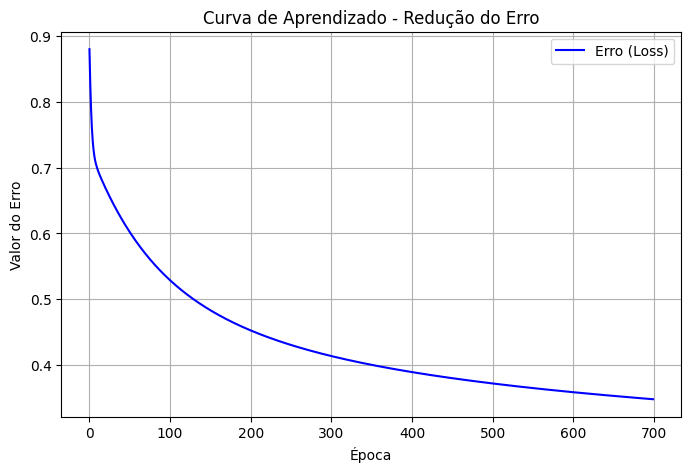

In [17]:
# Criando o Gráfico de Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(historico_erro, color='blue', label='Erro (Loss)')
plt.title('Curva de Aprendizado - Redução do Erro')
plt.xlabel('Época')
plt.ylabel('Valor do Erro')
plt.legend()
plt.grid(True)
plt.show()

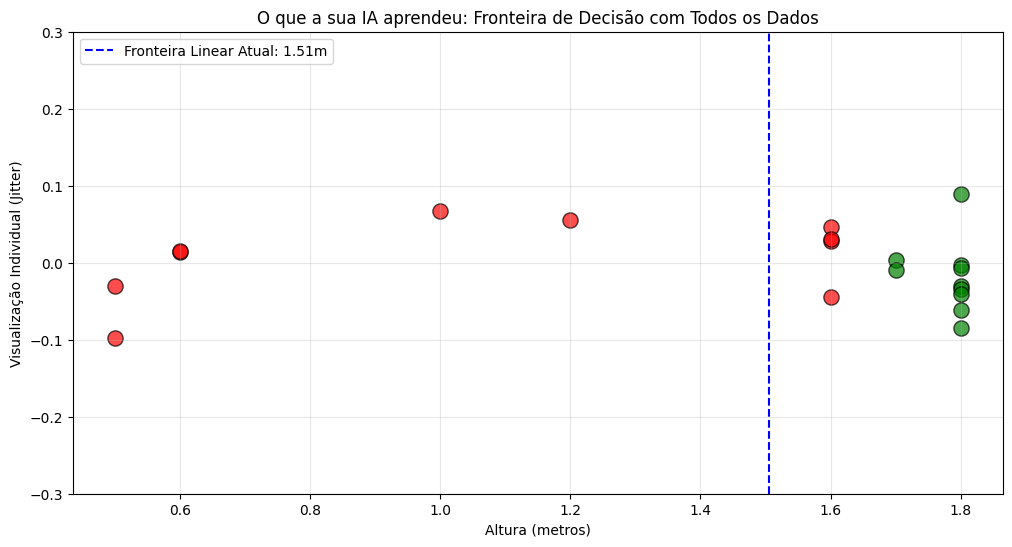

Número total de dados plotados: 20


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Transformando os dados para o gráfico
alturas = alturasPossiveis.numpy()
respostas = classificacaoPossivel.numpy()

# Criando a visualização
plt.figure(figsize=(12, 6))

# Bolinhas com "Jitter" e Transparência
for i in range(len(alturas)):
    cor = 'green' if respostas[i] == 1 else 'red'
    jitter_y = np.random.uniform(-0.1, 0.1)
    plt.scatter(alturas[i], jitter_y, color=cor, s=120, edgecolors='k', alpha=0.7)

# Descobrindo a Fronteira de Decisão Atual
peso = modelo.weight.item()
vies = modelo.bias.item()
# A fronteira é onde Peso * x + Viés = 0 -> x = -Viés / Peso
fronteira_num = -vies / peso

# Traçando a linha de decisão atual
plt.axvline(x=fronteira_num, color='blue', linestyle='--', label=f'Fronteira Linear Atual: {fronteira_num:.2f}m')

plt.title("O que a sua IA aprendeu: Fronteira de Decisão com Todos os Dados")
plt.xlabel("Altura (metros)")
plt.ylabel("Visualização Individual (Jitter)") # Eixo Y agora serve para separar as bolinhas
plt.ylim(-0.3, 0.3) # Ajusta o limite vertical para o jitter
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Número total de dados plotados: {len(alturas)}")